In [ ]:
SHOW DATABASES;

In [ ]:
CREATE DATABASE BUGBREW;

Query OK

In [ ]:
USE BUGBREW;

Query OK

In [ ]:
DROP table IRIS;

Query OK

In [ ]:
CREATE TABLE IRIS(
  Id INT PRIMARY KEY,
  SepalLengthCm DOUBLE,
  SepalWidthCm DOUBLE,
  PetalLengthCm DOUBLE,
  PetalWidthCm DOUBLE,
  Species VARCHAR(50)
);


Query OK

In [ ]:
LOAD DATA LOCAL INFILE '/home/iddhartha/mariadb_kernel/Iris.csv'
INTO TABLE IRIS
FIELDS TERMINATED BY ','
OPTIONALLY ENCLOSED BY '"'
LINES TERMINATED BY '\n'
IGNORE 1 LINES
(Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species);

Query OK

In [ ]:
SELECT * FROM IRIS;

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5,3.6,1.4,0.2,Iris-setosa
6,5.4,3.9,1.7,0.4,Iris-setosa
7,4.6,NULL,1.4,0.3,Iris-setosa
8,5,3.4,1.5,0.2,Iris-setosa
9,4.4,2.9,1.4,0.2,Iris-setosa
10,4.9,3.1,1.5,0.1,Iris-setosa


In [11]:
%missing

,missing,percent
Id,0,0.00
SepalLengthCm,2,1.33
SepalWidthCm,3,2.00
PetalLengthCm,1,0.67
PetalWidthCm,0,0.00
Species,0,0.00


In [12]:
%fillmissing strategy=median mode=preview

PREVIEW: missing counts per column:
Id: missing=0
SepalLengthCm: missing=2
SepalWidthCm: missing=3
PetalLengthCm: missing=1
PetalWidthCm: missing=0
Species: missing=0
PREVIEW: computed fill-values (best-effort):
Id: would fill with -> 75.5 (median via local preview)
SepalLengthCm: would fill with -> 5.8 (median via local preview)
SepalWidthCm: would fill with -> 3.0 (median via local preview)
PetalLengthCm: would fill with -> 4.4 (median via local preview)
PetalWidthCm: would fill with -> 0.1 (median via local preview)
Species: could NOT determine fill value (not numeric; cannot compute median locally); would skip


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,_null_columns,Id_filled_preview,SepalLengthCm_filled_preview,SepalWidthCm_filled_preview,PetalLengthCm_filled_preview,PetalWidthCm_filled_preview,Species_filled_preview
7,4.6,NaN,1.4,0.3,Iris-setosa,SepalWidthCm,7,4.6,3.0,1.4,0.3,Iris-setosa
17,5.4,NaN,1.3,0.1,Iris-setosa,SepalWidthCm,17,5.4,3.0,1.3,0.1,Iris-setosa
28,NaN,3.5,1.5,0.1,Iris-setosa,SepalLengthCm,28,5.8,3.5,1.5,0.1,Iris-setosa
31,4.8,3.1,NaN,0.1,Iris-setosa,PetalLengthCm,31,4.8,3.1,4.4,0.1,Iris-setosa
37,5.5,NaN,1.3,0.1,Iris-setosa,SepalWidthCm,37,5.5,3.0,1.3,0.1,Iris-setosa
150,NaN,3.0,5.1,0.1,Iris-virginica,SepalLengthCm,150,5.8,3.0,5.1,0.1,Iris-virginica


In [13]:
%dropmissing columns=SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species mode=apply table=IRIS confirm=true

Apply completed: original preserved as IRIS_backup_29adf350d1ab4121.


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
6,5.4,3.9,1.7,0.4,Iris-setosa
8,5.0,3.4,1.5,0.2,Iris-setosa
9,4.4,2.9,1.4,0.2,Iris-setosa
10,4.9,3.1,1.5,0.1,Iris-setosa
11,5.4,3.7,1.5,0.2,Iris-setosa


In [ ]:
%dropmissing mode=rollback rollback_token=

In [14]:
%stats

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,54.450000,5.536000,3.069000,3.075000,0.112000
std,30.396828,0.668561,0.466601,1.533951,0.040899
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,28.500000,5.000000,2.800000,1.500000,0.100000
50%,55.500000,5.500000,3.000000,3.550000,0.100000
75%,80.250000,6.000000,3.400000,4.500000,0.100000
max,105.000000,7.100000,4.400000,6.000000,0.400000


In [15]:
%outliers

Outlier detection completed (non in-place). Summary:
Column 'Id': detected 0 outlier(s) using iqr.
Column 'SepalLengthCm': detected 0 outlier(s) using iqr.
Column 'SepalWidthCm': detected 1 outlier(s) using iqr.
Column 'PetalLengthCm': detected 0 outlier(s) using iqr.
Column 'PetalWidthCm': detected 10 outlier(s) using iqr.
Results stored in data['last_select_outliers'] (original data['last_select'] unchanged).


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Id_is_outlier,SepalLengthCm_is_outlier,SepalWidthCm_is_outlier,PetalLengthCm_is_outlier,PetalWidthCm_is_outlier
1,5.1,3.5,1.4,0.2,Iris-setosa,False,False,False,False,True
2,4.9,3.0,1.4,0.2,Iris-setosa,False,False,False,False,True
3,4.7,3.2,1.3,0.2,Iris-setosa,False,False,False,False,True
4,4.6,3.1,1.5,0.2,Iris-setosa,False,False,False,False,True
5,5.0,3.6,1.4,0.2,Iris-setosa,False,False,False,False,True
6,5.4,3.9,1.7,0.4,Iris-setosa,False,False,False,False,True
8,5.0,3.4,1.5,0.2,Iris-setosa,False,False,False,False,True
9,4.4,2.9,1.4,0.2,Iris-setosa,False,False,False,False,True
10,4.9,3.1,1.5,0.1,Iris-setosa,False,False,False,False,False
11,5.4,3.7,1.5,0.2,Iris-setosa,False,False,False,False,True


In [16]:
%dropoutliers mode=preview

PREVIEW (local): would drop 11 row(s) (from 100 to 89).
Column 'Id': detected 0 outlier(s) using iqr.
Column 'SepalLengthCm': detected 0 outlier(s) using iqr.
Column 'SepalWidthCm': detected 1 outlier(s) using iqr.
Column 'PetalLengthCm': detected 0 outlier(s) using iqr.
Column 'PetalWidthCm': detected 10 outlier(s) using iqr.


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,_outlier_cols
1,5.1,3.5,1.4,0.2,Iris-setosa,
2,4.9,3.0,1.4,0.2,Iris-setosa,
3,4.7,3.2,1.3,0.2,Iris-setosa,
4,4.6,3.1,1.5,0.2,Iris-setosa,
5,5.0,3.6,1.4,0.2,Iris-setosa,
6,5.4,3.9,1.7,0.4,Iris-setosa,
8,5.0,3.4,1.5,0.2,Iris-setosa,
9,4.4,2.9,1.4,0.2,Iris-setosa,
11,5.4,3.7,1.5,0.2,Iris-setosa,
12,4.8,3.4,1.6,0.2,Iris-setosa,


In [17]:
%clipoutliers columns=SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species mode=apply table=IRIS confirm=true

Apply completed: original preserved as IRIS_backup_89cc522a9f0c4aad.


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.1,Iris-setosa
2,4.9,3.0,1.4,0.1,Iris-setosa
3,4.7,3.2,1.3,0.1,Iris-setosa
4,4.6,3.1,1.5,0.1,Iris-setosa
5,5.0,3.6,1.4,0.1,Iris-setosa
6,5.4,3.9,1.7,0.1,Iris-setosa
8,5.0,3.4,1.5,0.1,Iris-setosa
9,4.4,2.9,1.4,0.1,Iris-setosa
10,4.9,3.1,1.5,0.1,Iris-setosa
11,5.4,3.7,1.5,0.1,Iris-setosa


In [18]:
%encode method=onehot columns=Species drop_original=false

PREVIEW (local):
Local: Column 'Species' unique non-null values: 3 (showing up to 10): ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
PREVIEW (local) estimated created columns: 3
Preview sample with encoded columns (showing 100 rows):


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Species_Iris-setosa,Species_Iris-versicolor,Species_Iris-virginica
1,5.1,3.5,1.4,0.1,Iris-setosa,1.0,0.0,0.0
2,4.9,3.0,1.4,0.1,Iris-setosa,1.0,0.0,0.0
3,4.7,3.2,1.3,0.1,Iris-setosa,1.0,0.0,0.0
4,4.6,3.1,1.5,0.1,Iris-setosa,1.0,0.0,0.0
5,5.0,3.6,1.4,0.1,Iris-setosa,1.0,0.0,0.0
6,5.4,3.9,1.7,0.1,Iris-setosa,1.0,0.0,0.0
8,5.0,3.4,1.5,0.1,Iris-setosa,1.0,0.0,0.0
9,4.4,2.9,1.4,0.1,Iris-setosa,1.0,0.0,0.0
10,4.9,3.1,1.5,0.1,Iris-setosa,1.0,0.0,0.0
11,5.4,3.7,1.5,0.1,Iris-setosa,1.0,0.0,0.0


In [19]:
%encode method=label columns=Species drop_original=true mode=apply confirm=true

Encoded columns in-place and updated last_select.


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_lbl
1,5.1,3.5,1.4,0.1,0
2,4.9,3.0,1.4,0.1,0
3,4.7,3.2,1.3,0.1,0
4,4.6,3.1,1.5,0.1,0
5,5.0,3.6,1.4,0.1,0
6,5.4,3.9,1.7,0.1,0
8,5.0,3.4,1.5,0.1,0
9,4.4,2.9,1.4,0.1,0
10,4.9,3.1,1.5,0.1,0
11,5.4,3.7,1.5,0.1,0


In [20]:
%standardize mode=preview

PREVIEW (local):
Local: Column 'Id': mean=54.45, std=30.244462303039874
Local: Column 'SepalLengthCm': mean=5.535999999999999, std=0.6652097413598211
Local: Column 'SepalWidthCm': mean=3.067999999999999, std=0.46149322855270586
Local: Column 'PetalLengthCm': mean=3.0750000000000006, std=1.526261773091366
Local: Column 'PetalWidthCm': mean=0.09999999999999998, std=2.7755575615628914e-17
Local: Column 'Species_lbl': mean=0.6, std=0.5830951894845301


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_lbl,Id_std_preview,SepalLengthCm_std_preview,SepalWidthCm_std_preview,PetalLengthCm_std_preview,PetalWidthCm_std_preview,Species_lbl_std_preview
1,5.1,3.5,1.4,0.1,0,-1.767266,-0.655432,0.936092,-1.097453,1.0,-1.028992
2,4.9,3.0,1.4,0.1,0,-1.734202,-0.956089,-0.147348,-1.097453,1.0,-1.028992
3,4.7,3.2,1.3,0.1,0,-1.701138,-1.256746,0.286028,-1.162972,1.0,-1.028992
4,4.6,3.1,1.5,0.1,0,-1.668074,-1.407075,0.069340,-1.031933,1.0,-1.028992
5,5.0,3.6,1.4,0.1,0,-1.635010,-0.805761,1.152780,-1.097453,1.0,-1.028992
6,5.4,3.9,1.7,0.1,0,-1.601946,-0.204447,1.802843,-0.900894,1.0,-1.028992
8,5.0,3.4,1.5,0.1,0,-1.535818,-0.805761,0.719404,-1.031933,1.0,-1.028992
9,4.4,2.9,1.4,0.1,0,-1.502754,-1.707732,-0.364036,-1.097453,1.0,-1.028992
10,4.9,3.1,1.5,0.1,0,-1.469691,-0.956089,0.069340,-1.031933,1.0,-1.028992
11,5.4,3.7,1.5,0.1,0,-1.436627,-0.204447,1.369468,-1.031933,1.0,-1.028992


In [21]:
%normalize columns=SepalLengthCm,SepalWidthCm,PetalLengthCm mode=apply confirm=true 

Normalized 3 column(s) to range (0.0, 1.0). Updated data['last_select'] in-place.


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_lbl
1,0.285714,0.652174,0.08,0.1,0
2,0.214286,0.434783,0.08,0.1,0
3,0.142857,0.521739,0.06,0.1,0
4,0.107143,0.478261,0.10,0.1,0
5,0.250000,0.695652,0.08,0.1,0
6,0.392857,0.826087,0.14,0.1,0
8,0.250000,0.608696,0.10,0.1,0
9,0.035714,0.391304,0.08,0.1,0
10,0.214286,0.478261,0.10,0.1,0
11,0.392857,0.739130,0.10,0.1,0


In [22]:
%splitdata test_size=0.2 val_size=0.1 stratify=Species_lbl random_state=42

Split completed: total=100, train=70, test=20, val=10.


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_lbl
77,0.892857,0.347826,0.76,0.1,1
60,0.321429,0.304348,0.58,0.1,1
40,0.285714,0.608696,0.10,0.1,0
14,0.000000,0.434783,0.02,0.1,0
74,0.642857,0.347826,0.74,0.1,1
1,0.285714,0.652174,0.08,0.1,0
27,0.250000,0.608696,0.12,0.1,0
85,0.392857,0.434783,0.70,0.1,1
68,0.535714,0.304348,0.62,0.1,1
2,0.214286,0.434783,0.08,0.1,0


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_lbl
81,0.428571,0.173913,0.56,0.1,1
26,0.250000,0.434783,0.12,0.1,0
38,0.214286,0.478261,0.10,0.1,0
94,0.250000,0.130435,0.46,0.1,1
11,0.392857,0.739130,0.10,0.1,0
8,0.250000,0.608696,0.10,0.1,0
56,0.500000,0.347826,0.70,0.1,1
72,0.642857,0.347826,0.60,0.1,1
19,0.500000,0.782609,0.14,0.1,0
91,0.428571,0.260870,0.68,0.1,1


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_lbl
70,0.464286,0.217391,0.58,0.1,1
59,0.821429,0.391304,0.72,0.1,1
57,0.714286,0.565217,0.74,0.1,1
75,0.750000,0.391304,0.66,0.1,1
9,0.035714,0.391304,0.08,0.1,0
33,0.321429,0.913043,0.10,0.1,0
23,0.107143,0.695652,0.00,0.1,0
54,0.428571,0.130435,0.60,0.1,1
21,0.392857,0.608696,0.14,0.1,0
25,0.178571,0.608696,0.18,0.1,0


In [23]:
%select_features target=Species_lbl problem=classification k=4

Feature,Score
PetalLengthCm,624.413887
Id,122.246919
SepalLengthCm,49.475597
PetalWidthCm,33.500000
SepalWidthCm,24.338860


Selected 4 features saved to data['selected_features']: PetalLengthCm, Id, SepalLengthCm, PetalWidthCm


In [24]:
%select_model target=Species_lbl problem=classification 

Model,accuracy_Mean,accuracy_Std,f1_Mean,f1_Std,precision_Mean,precision_Std,recall_Mean,recall_Std
gbm,1.0000,0.0000,0.9289,0.1422,1.0000,0.0000,0.9143,0.1292
ada,1.0000,0.0000,0.9289,0.1422,0.9250,0.1500,1.0000,0.0000
lightgbm,0.9857,0.0286,0.9289,0.1422,0.9250,0.1500,0.9333,0.1333
rf,0.9857,0.0286,0.9289,0.1422,0.9250,0.1500,0.9333,0.1333
catboost,0.9857,0.0286,0.9289,0.1422,0.9250,0.1500,0.9333,0.1333
logistic,0.9571,0.0571,0.9520,0.0597,0.9500,0.0667,0.9714,0.0381
xgboost,0.9571,0.0571,0.8476,0.1874,0.8393,0.1976,0.8571,0.1756
knn,0.9571,0.0571,0.9520,0.0597,0.9500,0.0667,0.9714,0.0381
svm,0.9000,0.0969,0.6844,0.1689,0.6728,0.1719,0.7048,0.1576
mlp,0.8286,0.2148,0.4702,0.2870,0.7220,0.3104,0.5667,0.2494


Best model 'gbm' (mean accuracy=1.0000) saved to data['best_model'].


In [25]:
%train_model features=PetalLengthCm,SepalLengthCm,PetalWidthCm,SepalWidthCm target=Species_lbl problem=classification model=logistic

Model 'logistic' trained and saved to data['last_model']. problem=classification. train_rows=70


Accuracy,0.9500
Precision (w),0.9045
Recall (w),0.9500
F1 (w),0.9262
ROC AUC,Requires numeric y for ROC AUC.

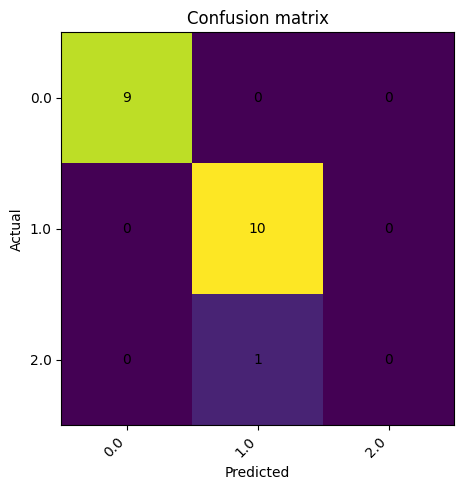

Species_lbl,_predicted,_pred_proba
1,1,"[0.1568254770832685, 0.7713064473235676, 0.07186807559316397]"
1,1,"[0.06718779974737324, 0.8435489946780091, 0.0892632055746176]"
1,1,"[0.11193644578263154, 0.7807944605541814, 0.10726909366318703]"
1,1,"[0.0969971439337914, 0.8149505429793529, 0.0880523130868557]"
0,0,"[0.8433008108096057, 0.13829791543550074, 0.01840127375489365]"
0,0,"[0.895686730493734, 0.08380524435902056, 0.020508025147245475]"
0,0,"[0.9268617694515947, 0.061193135907732926, 0.011945094640672366]"
1,1,"[0.13151754326324983, 0.8012709935000745, 0.06721146323667562]"
0,0,"[0.7596738139774813, 0.2071521192267119, 0.033174066795806915]"
0,0,"[0.8118943280777537, 0.1607394103543395, 0.027366261567906593]"


In [26]:
%evaluate_model

In [27]:
%savemodel model_name_in_data=last_model save_path='./saved_models/model.joblib'

Model from data['last_model'] saved to ./saved_models/model.joblib


In [28]:
%loadmodel load_path='./saved_models/model.joblib'

Loaded model from ./saved_models/model.joblib → data['last_model'] (features[4], target=Species_lbl)


In [29]:
%predict model_name=last_model data_name=[6.4,4.2,2.8,1.2] output_name=last_preds

Using inline feature values for prediction: {'PetalLengthCm': 6.4, 'SepalLengthCm': 4.2, 'PetalWidthCm': 2.8, 'SepalWidthCm': 1.2}


prediction
1


Predictions stored in data['last_preds'] with shape=(1, 1)


In [ ]:
SELECT * FROM magic_metadata;

id,command_name,arguments,execution_timestamp,affected_columns,operation_status,message,db_name,user_name,rollback_token,backup_table,original_table
1,missing,,2025-11-01 10:26:00,ALL_COLUMNS,success,%missing action=show examined 6 column(s); total_rows=150.,BUGBREW,,NULL,NULL,NULL
2,fillmissing,strategy=median mode=preview,2025-11-01 10:26:08,Id SepalLengthCm SepalWidthCm PetalLengthCm PetalWidthCm Species,preview,preview_computed_fill_values,BUGBREW,,NULL,NULL,NULL
3,dropmissing,"columns=SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species mode=apply table=IRIS confirm=true",2025-11-01 10:26:15,SepalLengthCm SepalWidthCm PetalLengthCm PetalWidthCm Species,applied,applied_backup=IRIS_backup_c8cac3251a844d7b,BUGBREW,,c8cac3251a844d7b,IRIS_backup_c8cac3251a844d7b,IRIS
4,missing,,2025-11-01 10:29:32,ALL_COLUMNS,success,%missing action=show examined 6 column(s); total_rows=150.,BUGBREW,,NULL,NULL,NULL
5,fillmissing,strategy=median mode=preview,2025-11-01 10:29:38,Id SepalLengthCm SepalWidthCm PetalLengthCm PetalWidthCm Species,preview,preview_computed_fill_values,BUGBREW,,NULL,NULL,NULL
6,dropmissing,"columns=SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species mode=apply table=IRIS confirm=true",2025-11-01 10:29:46,SepalLengthCm SepalWidthCm PetalLengthCm PetalWidthCm Species,applied,applied_backup=IRIS_backup_29adf350d1ab4121,BUGBREW,,29adf350d1ab4121,IRIS_backup_29adf350d1ab4121,IRIS
7,stats,,2025-11-01 10:30:13,ALL_COLUMNS,success,Stats computed for 5 column(s); total_rows=100; percentiles=; include=numeric.,BUGBREW,,NULL,NULL,NULL
8,outliers,,2025-11-01 10:30:18,Id SepalLengthCm SepalWidthCm PetalLengthCm PetalWidthCm,success,Column 'Id': detected 0 outlier(s) using iqr. Column 'SepalLengthCm': detected 0 outlier(s) using iqr. Column 'SepalWidthCm': detected 1 outlier(s) using iqr. Column 'PetalLengthCm': detected 0 outlier(s) using iqr. Column 'PetalWidthCm': detected 10 outlier(s) using iqr.,BUGBREW,,NULL,NULL,NULL
9,dropoutliers,mode=preview,2025-11-01 10:30:25,Id SepalLengthCm SepalWidthCm PetalLengthCm PetalWidthCm,preview,preview_completed,BUGBREW,,NULL,NULL,NULL
10,clipoutliers,"columns=SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species mode=apply table=IRIS confirm=true",2025-11-01 10:30:29,SepalLengthCm SepalWidthCm PetalLengthCm PetalWidthCm,applied,applied_backup=IRIS_backup_89cc522a9f0c4aad,BUGBREW,,89cc522a9f0c4aad,IRIS_backup_89cc522a9f0c4aad,IRIS
